# 05 — CIFAR-10 completo: ganhos e limites do aumento de dados

Este experimento amplia o MNIST do notebook 02 para **60.000 imagens RGB, 10 classes**, usando todos os dados oficiais: 45.000 para treino, 5.000 para validação e 10.000 para teste. Fonte: [CIFAR-10, Krizhevsky](https://www.cs.toronto.edu/~kriz/cifar.html).

É uma reprodução **experimental dos mecanismos** discutidos no [survey, §4.2](https://arxiv.org/abs/2204.08610v2), não uma reprodução das acurácias de Wide-ResNet/DenseNet. Utilizamos uma CNN pequena, inicializada do zero, sem pesos externos, para permitir execução em CPU. Não é um experimento de detecção COCO; o notebook 06 usa uma fotografia e anotações COCO para explicar as transformações.

Execute em ordem. O download inicial pelo espelho FastAI/AWS tem ~129 MB; o conteúdo é o CIFAR-10 de 60 mil imagens. As 18 execuções (6 políticas × 3 sementes) podem levar dezenas de minutos em CPU. Não reduza o conjunto apenas para obter um ganho favorável: resultados negativos também são preservados.

In [1]:
from pathlib import Path
import os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
import csv
import json
import time
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision.datasets import ImageFolder
from PIL import Image
import tarfile
import urllib.request
import albumentations as A
import cv2

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'seminar_3/notebooks').is_dir())
SEMINAR = ROOT/'seminar_3'
OUT = SEMINAR/'data/outputs/color'
DATA = SEMINAR/'data/raw/cifar10'
OUT.mkdir(parents=True, exist_ok=True)
DATA.parent.mkdir(parents=True, exist_ok=True)
cv2.setNumThreads(1)
torch.set_num_threads(6)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')  # Mantém o protocolo entregue; pode ser alterado com registro.

def save_csv(path, rows):
    with path.open('w', newline='', encoding='utf-8') as f:
        writer=csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader(); writer.writerows(rows)

archive = DATA.parent/'cifar10.tgz'
if not (DATA/'train').is_dir():
    if not archive.exists():
        urllib.request.urlretrieve('https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz', archive)
    with tarfile.open(archive) as stream:
        stream.extractall(DATA.parent, filter='data')
train_data=ImageFolder(DATA/'train')
test_data=ImageFolder(DATA/'test')
assert len(train_data)==50000 and len(test_data)==10000

## 1. Split antes das transformações
Por classe: 4.500 imagens de treino, 500 de validação, 1.000 do teste oficial. A validação monitora aprendizagem; **a última época** será avaliada no teste. Não escolhemos política, intensidade ou época usando o teste.

As três sementes variam inicialização e augmentations. O split é o mesmo: o desvio entre sementes não mede a incerteza sobre novos datasets.

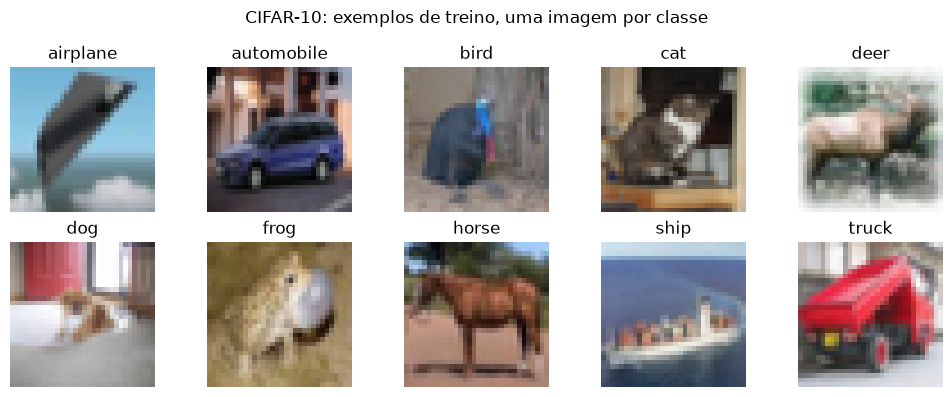

In [2]:
SPLIT_SEED=558
rng=np.random.default_rng(SPLIT_SEED)
labels=np.array(train_data.targets)
train_ids, val_ids=[],[]
for category in range(10):
    ids=rng.permutation(np.flatnonzero(labels==category))
    train_ids.extend(ids[:4500]); val_ids.extend(ids[4500:])
train_ids=np.array(train_ids); val_ids=np.array(val_ids)
assert set(train_ids).isdisjoint(val_ids)
assert len(set(train_ids)|set(val_ids))==50000
assert np.all(np.bincount(labels[train_ids])==4500)
assert np.all(np.bincount(labels[val_ids])==500)
np.savez_compressed(OUT/'cifar10_split.npz', train=train_ids, validation=val_ids, test=np.arange(10000))
all_train=np.stack([np.asarray(Image.open(path).convert('RGB')) for path, _ in train_data.samples])
all_test=np.stack([np.asarray(Image.open(path).convert('RGB')) for path, _ in test_data.samples])
raw_train=all_train[train_ids]
y_train=torch.tensor(labels[train_ids], dtype=torch.long, device=DEVICE)
raw_val=all_train[val_ids]
y_val=torch.tensor(labels[val_ids], dtype=torch.long, device=DEVICE)
raw_test=all_test
y_test=torch.tensor(test_data.targets, dtype=torch.long, device=DEVICE)

def tensor(images):
    return torch.from_numpy(np.ascontiguousarray(images.transpose(0,3,1,2))).to(DEVICE, dtype=torch.float32)/255

fig,axes=plt.subplots(2,5,figsize=(10,4))
for i,ax in enumerate(axes.flat):
    index=np.flatnonzero(labels[train_ids]==i)[0]
    ax.imshow(raw_train[index]); ax.set_title(train_data.classes[i]); ax.axis('off')
fig.suptitle('CIFAR-10: exemplos de treino, uma imagem por classe')
fig.tight_layout(); fig.savefig(OUT/'cifar10_classes.png', dpi=180); plt.show()

## 2. Comparação controlada de seis políticas

| Política | Operações |
|---|---|
| Sem augmentation | Apenas divisão por 255 |
| Geometria | Padding refletido até 40×40 → crop 32×32; flip horizontal p=0,5 |
| Geometria + cor | Base geométrica + ColorJitter (brilho/contraste/saturação 0,2; hue 0,05), p=0,8 |
| Geometria + Cutout | Base geométrica + apagamento 8×8, p=0,5 |
| Geometria + Mixup | Base geométrica + mistura de lote, λ ~ Beta(0,4; 0,4) |
| Geometria + CutMix | Base geométrica + troca de retângulo, λ ~ Beta(1; 1) |

Mixup e CutMix ponderam a perda com os **dois rótulos**; CutMix recalcula λ pela área real após cortar nas bordas. As políticas derivadas são comparadas tanto à referência sem augmentation quanto à base geométrica.

A mesma semente reinicia pesos e sequência de lotes para cada política. `Compose` é criado uma vez por execução, não por imagem. Não realizamos busca de hiperparâmetros.

In [3]:
SEEDS=[7,23,42]
EPOCHS=20
BATCH=256
POLICIES=['Sem augmentation','Geometria','Geometria + cor','Geometria + Cutout','Geometria + Mixup','Geometria + CutMix']

def make_augmentation(policy, seed):
    transforms=[]
    if policy != 'Sem augmentation':
        transforms=[A.PadIfNeeded(40,40,border_mode=cv2.BORDER_REFLECT_101,p=1),
                    A.RandomCrop(32,32,p=1), A.HorizontalFlip(p=0.5)]
    if policy == 'Geometria + cor':
        transforms.append(A.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.05,p=0.8))
    if policy == 'Geometria + Cutout':
        transforms.append(A.CoarseDropout(num_holes_range=(1,1),hole_height_range=(8,8),hole_width_range=(8,8),fill=0,p=0.5))
    return A.Compose(transforms,seed=seed)

def make_model():
    return nn.Sequential(
        nn.Conv2d(3,12,3,stride=2,padding=1),nn.ReLU(),
        nn.Conv2d(12,24,3,stride=2,padding=1),nn.ReLU(),
        nn.Conv2d(24,48,3,stride=2,padding=1),nn.ReLU(),
        nn.Flatten(),nn.Linear(48*4*4,128),nn.ReLU(),nn.Linear(128,10),
    ).to(DEVICE)

def mix_batch(xb, yb, kind, rng):
    pair=torch.as_tensor(rng.permutation(len(xb)),device=DEVICE)
    alpha=0.4 if kind=='Mixup' else 1.0
    lam=float(rng.beta(alpha,alpha))
    if kind=='Mixup':
        mixed=lam*xb+(1-lam)*xb[pair]
    else:
        h,w=xb.shape[-2:]
        cx,cy=rng.integers(w),rng.integers(h)
        patch_w,patch_h=int(w*np.sqrt(1-lam)),int(h*np.sqrt(1-lam))
        x1,x2=max(0,cx-patch_w//2),min(w,cx+(patch_w+1)//2)
        y1,y2=max(0,cy-patch_h//2),min(h,cy+(patch_h+1)//2)
        mixed=xb.clone()
        mixed[:,:,y1:y2,x1:x2]=xb[pair,:,y1:y2,x1:x2]
        lam=1-((x2-x1)*(y2-y1))/(h*w)
    return mixed,yb[pair],lam

# Check numérico: com intensidades constantes por imagem, a média revela a fração realmente misturada.
probe=torch.stack([torch.zeros(3,32,32),torch.ones(3,32,32)]).to(DEVICE)
for kind in ['Mixup','CutMix']:
    mixed,paired,lam=mix_batch(probe,torch.tensor([0,1],device=DEVICE),kind,np.random.default_rng(9))
    expected=lam*torch.tensor([0.,1.],device=DEVICE)+(1-lam)*paired.float()
    assert 0<=lam<=1 and torch.allclose(mixed.mean((1,2,3)),expected,atol=1e-6)
p1,p2=make_augmentation('Geometria',7),make_augmentation('Geometria',7)
assert all(np.array_equal(p1(image=im)['image'],p2(image=im)['image']) for im in raw_train[:5])
print('Parâmetros da CNN:',sum(p.numel() for p in make_model().parameters()))

Parâmetros da CNN: 113090


## 3. Treinamento real
Adam (lr=0,001), 20 épocas, lote 256; mesma quantidade de exemplos e atualizações em todas as políticas. Acurácia de validação é medida sem aumento.

O arquivo `progress.json` mostra a execução em andamento; `cifar10_runs.csv` e `cifar10_curves.csv` recebem resultados ao concluir cada execução. As perdas de Mixup/CutMix correspondem a alvos diferentes, portanto não devem ser comparadas diretamente à entropia cruzada dos alvos duros.

In [4]:
@torch.inference_mode()
def evaluate(model, images, targets):
    model.eval()
    predicted=[]
    for start in range(0,len(images),BATCH):
        predicted.append(model(tensor(images[start:start+BATCH])).argmax(1).cpu())
    predicted=torch.cat(predicted)
    accuracy=(predicted==targets.cpu()).float().mean().item()*100
    return accuracy,predicted.numpy()

# Perturbações fixadas antes do treino; não são novos datasets nem CIFAR-10-C.
shifted=np.zeros_like(raw_test)
shifted[:,:,4:]=raw_test[:,:,:-4]
dark=np.rint(raw_test.astype(np.float32)*0.65).astype(np.uint8)
assert shifted[:,:,:4].max()==0
protocol=dict(dataset='CIFAR-10',train=45000,validation=5000,test=10000,split_seed=SPLIT_SEED,
              seeds=SEEDS,epochs=EPOCHS,batch=BATCH,policies=POLICIES,device=str(DEVICE),threads=6,
              optimizer='Adam lr=0.001',selection='last epoch, no test selection',
              model=str(make_model()),parameters=sum(p.numel() for p in make_model().parameters()),
              perturbations={'shift':'4 pixels right, zero fill','dark':'uint8 round(image * 0.65)'},
              python=platform.python_version(),torch=torch.__version__,albumentations=A.__version__,
              numpy=np.__version__,platform=platform.platform())
(OUT/'cifar10_protocol.json').write_text(json.dumps(protocol,indent=2))
rows,curves=[],[]
for seed in SEEDS:
    for policy in POLICIES:
        torch.manual_seed(seed)
        model=make_model()
        optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
        augmentation=make_augmentation(policy,seed)
        order_rng=np.random.default_rng(seed+1000)
        mix_rng=np.random.default_rng(seed+2000)
        started=time.perf_counter()
        for epoch in range(1,EPOCHS+1):
            model.train(); total_loss=0.
            order=order_rng.permutation(len(raw_train))
            for start in range(0,len(order),BATCH):
                ids=order[start:start+BATCH]
                images=raw_train[ids]
                if policy!='Sem augmentation':
                    images=np.stack([augmentation(image=im)['image'] for im in images])
                xb=tensor(images); yb=y_train[ids]
                optimizer.zero_grad()
                if policy.endswith(('Mixup','CutMix')):
                    xb,y_pair,lam=mix_batch(xb,yb,policy.split()[-1],mix_rng)
                    logits=model(xb)
                    loss=lam*nn.functional.cross_entropy(logits,yb)+(1-lam)*nn.functional.cross_entropy(logits,y_pair)
                else:
                    loss=nn.functional.cross_entropy(model(xb),yb)
                loss.backward(); optimizer.step()
                total_loss+=loss.item()*len(ids)
            assert np.isfinite(total_loss)
            val_acc,_=evaluate(model,raw_val,y_val)
            curve=dict(seed=seed,policy=policy,epoch=epoch,train_loss=total_loss/len(raw_train),validation_accuracy=val_acc)
            curves.append(curve)
            (OUT/'progress.json').write_text(json.dumps({**curve,'completed_runs':len(rows),'total_runs':len(SEEDS)*len(POLICIES)}))
            if epoch in [1,5,10,15,EPOCHS]:
                print(f'{seed} | {policy} | época {epoch:2}/{EPOCHS} | val={val_acc:.2f}%',flush=True)
        training_seconds=time.perf_counter()-started
        clean_acc,_=evaluate(model,raw_test,y_test)
        shift_acc,_=evaluate(model,shifted,y_test)
        dark_acc,_=evaluate(model,dark,y_test)
        train_acc,_=evaluate(model,raw_train,y_train)
        rows.append(dict(seed=seed,policy=policy,train_accuracy=train_acc,validation_accuracy=val_acc,
                         clean_accuracy=clean_acc,shift_accuracy=shift_acc,dark_accuracy=dark_acc,training_seconds=training_seconds))
        save_csv(OUT/'cifar10_runs.csv',rows); save_csv(OUT/'cifar10_curves.csv',curves)
        print(f'FINAL {seed} | {policy} | limpo={clean_acc:.2f}% | deslocado={shift_acc:.2f}% | escuro={dark_acc:.2f}%',flush=True)
assert len(rows)==18 and len(curves)==18*EPOCHS
assert all(0<=r[key]<=100 for r in rows for key in ['clean_accuracy','shift_accuracy','dark_accuracy'])
assert all(r['clean_accuracy']>20 for r in rows if r['policy']=='Sem augmentation')
(OUT/'progress.json').write_text(json.dumps({'status':'complete','completed_runs':len(rows),'total_runs':len(SEEDS)*len(POLICIES)}))

7 | Sem augmentation | época  1/20 | val=38.48%


7 | Sem augmentation | época  5/20 | val=51.58%


7 | Sem augmentation | época 10/20 | val=57.96%


7 | Sem augmentation | época 15/20 | val=60.68%


7 | Sem augmentation | época 20/20 | val=62.30%


...

42 | Geometria + CutMix | época  5/20 | val=44.96%


42 | Geometria + CutMix | época 10/20 | val=50.86%


42 | Geometria + CutMix | época 15/20 | val=54.10%


42 | Geometria + CutMix | época 20/20 | val=57.20%


FINAL 42 | Geometria + CutMix | limpo=57.39% | deslocado=45.34% | escuro=44.05%


## 4. Ganhos pareados e robustez
Os testes deslocado e escurecido reutilizam os mesmos 10.000 exemplos de teste. Medem sensibilidade a perturbações conhecidas, não generalização universal. Barras de erro são desvio padrão amostral entre três sementes, não intervalos de confiança.

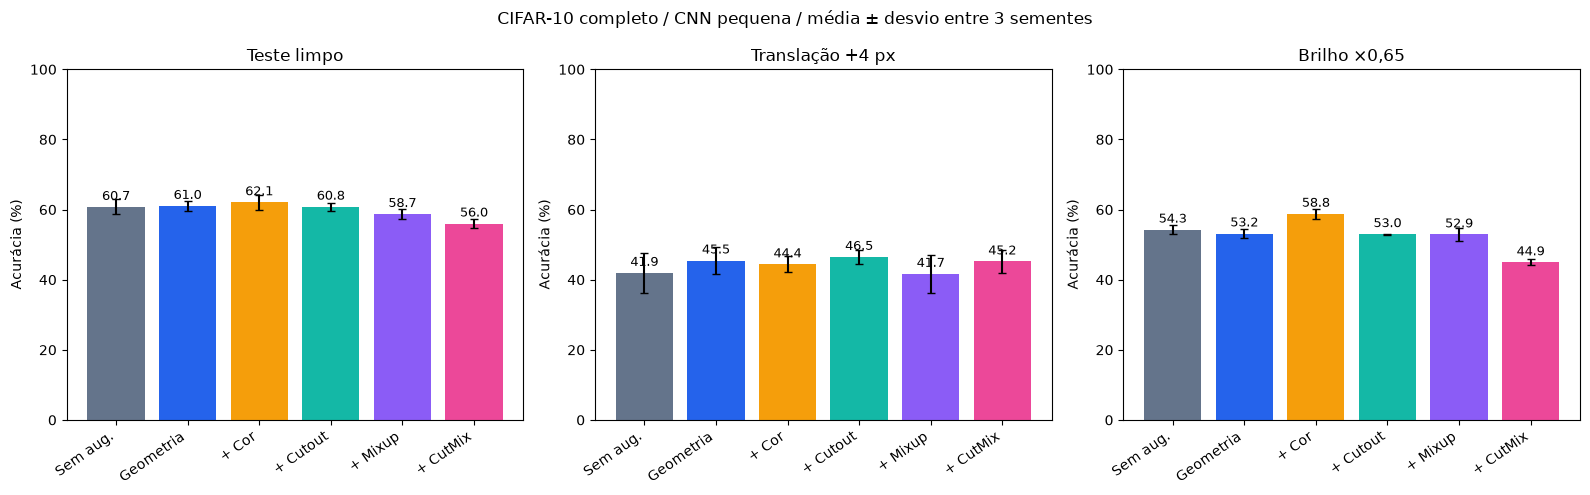

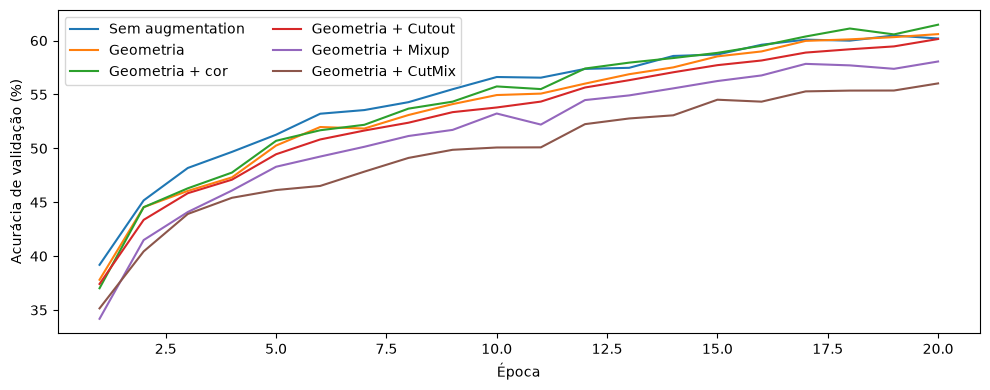

Sem augmentation      : Δ sem aug. = +0.00 ± 0.00 p.p.; Δ geometria = -0.30 p.p.
Geometria             : Δ sem aug. = +0.30 ± 1.53 p.p.; Δ geometria = +0.00 p.p.
Geometria + cor       : Δ sem aug. = +1.34 ± 0.76 p.p.; Δ geometria = +1.04 p.p.
Geometria + Cutout    : Δ sem aug. = +0.07 ± 2.44 p.p.; Δ geometria = -0.23 p.p.
Geometria + Mixup     : Δ sem aug. = -2.02 ± 0.80 p.p.; Δ geometria = -2.32 p.p.
Geometria + CutMix    : Δ sem aug. = -4.74 ± 1.90 p.p.; Δ geometria = -5.04 p.p.


In [5]:
summary=[]
for policy in POLICIES:
    group=[r for r in rows if r['policy']==policy]
    item={'policy':policy}
    for metric in ['clean_accuracy','shift_accuracy','dark_accuracy']:
        values=[r[metric] for r in group]
        item[metric+'_mean']=float(np.mean(values)); item[metric+'_std']=float(np.std(values,ddof=1))
    for baseline,tag in [('Sem augmentation','vs_none'),('Geometria','vs_geometry')]:
        gains=[r['clean_accuracy']-next(b['clean_accuracy'] for b in rows if b['seed']==r['seed'] and b['policy']==baseline) for r in group]
        item[tag+'_mean_pp']=float(np.mean(gains)); item[tag+'_std_pp']=float(np.std(gains,ddof=1))
    summary.append(item)
save_csv(OUT/'cifar10_summary.csv',summary)
fig,axes=plt.subplots(1,3,figsize=(16,5))
short=['Sem aug.','Geometria','+ Cor','+ Cutout','+ Mixup','+ CutMix']
for ax,metric,title in zip(axes,['clean_accuracy','shift_accuracy','dark_accuracy'],['Teste limpo','Translação +4 px','Brilho ×0,65'],strict=True):
    means=[r[metric+'_mean'] for r in summary]; std=[r[metric+'_std'] for r in summary]
    ax.bar(range(6),means,yerr=std,capsize=3,color=['#64748b','#2563eb','#f59e0b','#14b8a6','#8b5cf6','#ec4899'])
    ax.set_xticks(range(6),short,rotation=35,ha='right'); ax.set(title=title,ylabel='Acurácia (%)',ylim=(0,100))
    for i,v in enumerate(means): ax.text(i,v+2,f'{v:.1f}',ha='center',fontsize=9)
fig.suptitle('CIFAR-10 completo / CNN pequena / média ± desvio entre 3 sementes')
fig.tight_layout(); fig.savefig(OUT/'cifar10_accuracy.png',dpi=180,bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(figsize=(10,4))
for policy in POLICIES:
    mean=[np.mean([r['validation_accuracy'] for r in curves if r['policy']==policy and r['epoch']==e]) for e in range(1,EPOCHS+1)]
    ax.plot(range(1,EPOCHS+1),mean,label=policy)
ax.set(xlabel='Época',ylabel='Acurácia de validação (%)'); ax.legend(ncols=2); fig.tight_layout()
fig.savefig(OUT/'cifar10_learning.png',dpi=180,bbox_inches='tight'); plt.show()
for r in summary:
    print(f"{r['policy']:22}: Δ sem aug. = {r['vs_none_mean_pp']:+.2f} ± {r['vs_none_std_pp']:.2f} p.p.; Δ geometria = {r['vs_geometry_mean_pp']:+.2f} p.p.")

## 5. Discussão para o seminário
- Identifique quais políticas ganharam ou perderam no teste limpo; não presuma que todas ajudem.
- Compare cada adição à **Geometria**, para separar o efeito da base do efeito de Mixup/CutMix/cor/apagamento.
- Compare teste limpo e perturbado: a invariância aprendida pode ter benefício específico.
- Observe validação e diferença treino–teste. Mais épocas ou outra arquitetura podem alterar os resultados.
- Os ganhos publicados pelo survey usam outras redes e protocolos. Estes números são medições locais com código, splits e condições registrados.

Os arquivos CSV, JSON e NPZ permitem auditar a execução. O notebook 06 gera imagens de cada transformação e uma animação com os resultados efetivamente medidos.